# Customer Engagement & Product Utilization Analytics
## European Central Bank - Churn Retention Strategy

**Author:** Data Analyst | **Mentor:** European Central Bank  
**Dataset:** European_Bank.csv (10,000 customers | France, Germany, Spain)  
**Objective:** Understand how engagement and product usage drive churn

---
### Contents
1. Setup & Imports
2. Data Loading & Validation
3. Feature Engineering (4 Engagement Profiles)
4. KPI Computation (all 5 KPIs)
5. Exploratory Data Analysis
6. Engagement Profile Analysis
7. Product Utilisation & Financial Analysis
8. Retention Strength Assessment
9. Predictive Modelling (4 models)
10. Risk Segmentation & Premium Customer Detection
11. Key Findings & Recommendations

## 1. Setup & Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay, classification_report
)
import pickle, os

# Colour palette
NAVY, BLUE, TEAL = '#0D1B2A', '#1B4F8A', '#00897B'
AMBER, RED       = '#F4A261', '#E63946'
PROFILES = ['Active Engaged', 'Active Low-Product',
            'Inactive High-Balance', 'Inactive Disengaged']
PCOLS = [TEAL, BLUE, AMBER, RED]
CMAP  = LinearSegmentedColormap.from_list('risk', [TEAL, AMBER, RED])
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#F8FAFB'})
os.makedirs('figures', exist_ok=True)
print("Setup complete")

Setup complete


## 2. Data Loading & Validation

In [45]:
df = pd.read_csv('European_Bank.csv')
df = df.drop([c for c in ['Year', 'CustomerId', 'Surname'] if c in df.columns], axis=1)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (10000, 11)
Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [46]:
print("** NULL VALUES **")
print(df.isnull().sum())
print("** BINARY VARIABLE CHECK **")
print("HasCrCard:    ", df['HasCrCard'].unique())
print("IsActiveMember:", df['IsActiveMember'].unique())
print("** CLASS BALANCE **")
vc = df['Exited'].value_counts()
print(f"Retained: {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"Churned : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"Imbalance: {vc[0]/vc[1]:.1f}:1")

** NULL VALUES **
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
** BINARY VARIABLE CHECK **
HasCrCard:     [1 0]
IsActiveMember: [1 0]
** CLASS BALANCE **
Retained: 7,963 (79.6%)
Churned : 2,037 (20.4%)
Imbalance: 3.9:1


In [47]:
df.describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## 3. Feature Engineering

We classify each customer into one of 4 engagement profiles as required by the ECB brief, and compute all derived variables needed for KPI calculation.

In [48]:
BAL75 = df['Balance'].quantile(0.75)
SAL75 = df['EstimatedSalary'].quantile(0.75)
print(f"High-balance threshold (P75): EUR {BAL75:,.0f}")
print(f"High-salary  threshold (P75): EUR {SAL75:,.0f}")

def engagement_profile(row):
    active   = row['IsActiveMember'] == 1
    multi    = row['NumOfProducts']  >= 2
    high_bal = row['Balance']        > BAL75
    if active and multi:         return 'Active Engaged'
    if active and not multi:     return 'Active Low-Product'
    if not active and high_bal:  return 'Inactive High-Balance'
    return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(engagement_profile, axis=1)

print("** ENGAGEMENT PROFILE DISTRIBUTION **")
for p in PROFILES:
    n = (df['EngagementProfile'] == p).sum()
    c = df[df['EngagementProfile'] == p]['Exited'].mean() * 100
    print(f"  {p:<35s}: {n:>5,} customers  |  Churn: {c:.1f}%")

High-balance threshold (P75): EUR 127,644
High-salary  threshold (P75): EUR 149,388
** ENGAGEMENT PROFILE DISTRIBUTION **
  Active Engaged                     : 2,588 customers  |  Churn: 9.7%
  Active Low-Product                 : 2,563 customers  |  Churn: 18.9%
  Inactive High-Balance              : 1,247 customers  |  Churn: 30.5%
  Inactive Disengaged                : 3,602 customers  |  Churn: 25.6%


In [49]:
# Relationship Strength Index (RSI) - combines activity, products, tenure
df['RSI'] = (df['IsActiveMember'] +
             (df['NumOfProducts'] - 1) / 3.0 +
             df['Tenure'] / 10.0)

df['RSI_Tier'] = pd.cut(df['RSI'],
    bins=[-0.01, 0.5, 1.2, 2.0, 3.1],
    labels=['Very Weak', 'Weak', 'Strong', 'Very Strong'])

# Salary-Balance Ratio (mismatch detection)
df['SBR']      = df['Balance'] / (df['EstimatedSalary'] + 1)
df['SBR_Tier'] = pd.cut(df['SBR'], bins=[-0.01, 0.3, 0.8, 100],
    labels=['Under-banked', 'Balanced', 'Over-banked'])

# Premium customer flags
df['IsPremium']    = ((df['Balance'] > BAL75) | (df['EstimatedSalary'] > SAL75)).astype(int)
df['PremInactive'] = ((df['IsPremium'] == 1) & (df['IsActiveMember'] == 0)).astype(int)

# Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'])

print(f"Premium inactive customers: {df['PremInactive'].sum():,}")
print(f"Total premium customers   : {df['IsPremium'].sum():,}")
print("All features created successfully")

Premium inactive customers: 2,154
Total premium customers   : 4,351
All features created successfully


## 4. KPI Computation - All 5 ECB KPIs

In [50]:
print("=" * 65)
print("   ECB CUSTOMER ENGAGEMENT KPI DASHBOARD")
print("=" * 65)

act   = df[df['IsActiveMember'] == 1]['Exited'].mean() * 100
inact = df[df['IsActiveMember'] == 0]['Exited'].mean() * 100

print(f"\nKPI 1 - Engagement Retention Ratio (ERR)")
print(f"   Active member churn   : {act:.1f}%")
print(f"   Inactive member churn : {inact:.1f}%")
print(f"   ERR = {inact/act:.2f}x  (inactive churn {inact/act:.1f}x more)")

p1 = df[df['NumOfProducts']==1]['Exited'].mean()*100
p2 = df[df['NumOfProducts']==2]['Exited'].mean()*100
print(f"\nKPI 2 - Product Depth Index")
print(f"   1 product  : {p1:.1f}%  |  2 products: {p2:.1f}% (sweet spot)")
print(f"   Cross-sell lift: {p1-p2:.1f}pp reduction by adding 1 product")

hbi = df[(df['Balance']>BAL75)&(df['IsActiveMember']==0)]['Exited'].mean()*100
hba = df[(df['Balance']>BAL75)&(df['IsActiveMember']==1)]['Exited'].mean()*100
print(f"\nKPI 3 - High-Balance Disengagement Rate")
print(f"   High-balance Active  : {hba:.1f}%  |  Inactive: {hbi:.1f}%")
print(f"   Risk premium for inactivity: +{hbi-hba:.1f}pp")

cc_no  = df[df['HasCrCard']==0]['Exited'].mean()*100
cc_yes = df[df['HasCrCard']==1]['Exited'].mean()*100
print(f"\nKPI 4 - Credit Card Stickiness Score")
print(f"   No card: {cc_no:.1f}%  |  Has card: {cc_yes:.1f}%  |  Diff: {cc_no-cc_yes:+.1f}pp")

rsi_vw = df[df['RSI']<0.5]['Exited'].mean()*100
rsi_vs = df[df['RSI']>2.0]['Exited'].mean()*100
print(f"\nKPI 5 - Relationship Strength Index (RSI)")
print(f"   Formula: IsActive + (Products-1)/3 + Tenure/10  [0 to 3]")
print(f"   Very Weak RSI  : {rsi_vw:.1f}% churn  |  Very Strong RSI: {rsi_vs:.1f}% churn")
print(f"   Range of impact: {rsi_vw-rsi_vs:.0f}pp improvement potential")
print("=" * 65)

   ECB CUSTOMER ENGAGEMENT KPI DASHBOARD

KPI 1 - Engagement Retention Ratio (ERR)
   Active member churn   : 14.3%
   Inactive member churn : 26.9%
   ERR = 1.88x  (inactive churn 1.9x more)

KPI 2 - Product Depth Index
   1 product  : 27.7%  |  2 products: 7.6% (sweet spot)
   Cross-sell lift: 20.1pp reduction by adding 1 product

KPI 3 - High-Balance Disengagement Rate
   High-balance Active  : 16.9%  |  Inactive: 30.5%
   Risk premium for inactivity: +13.6pp

KPI 4 - Credit Card Stickiness Score
   No card: 20.8%  |  Has card: 20.2%  |  Diff: +0.6pp

KPI 5 - Relationship Strength Index (RSI)
   Formula: IsActive + (Products-1)/3 + Tenure/10  [0 to 3]
   Very Weak RSI  : 32.1% churn  |  Very Strong RSI: 13.0% churn
   Range of impact: 19pp improvement potential


## 5. Exploratory Data Analysis

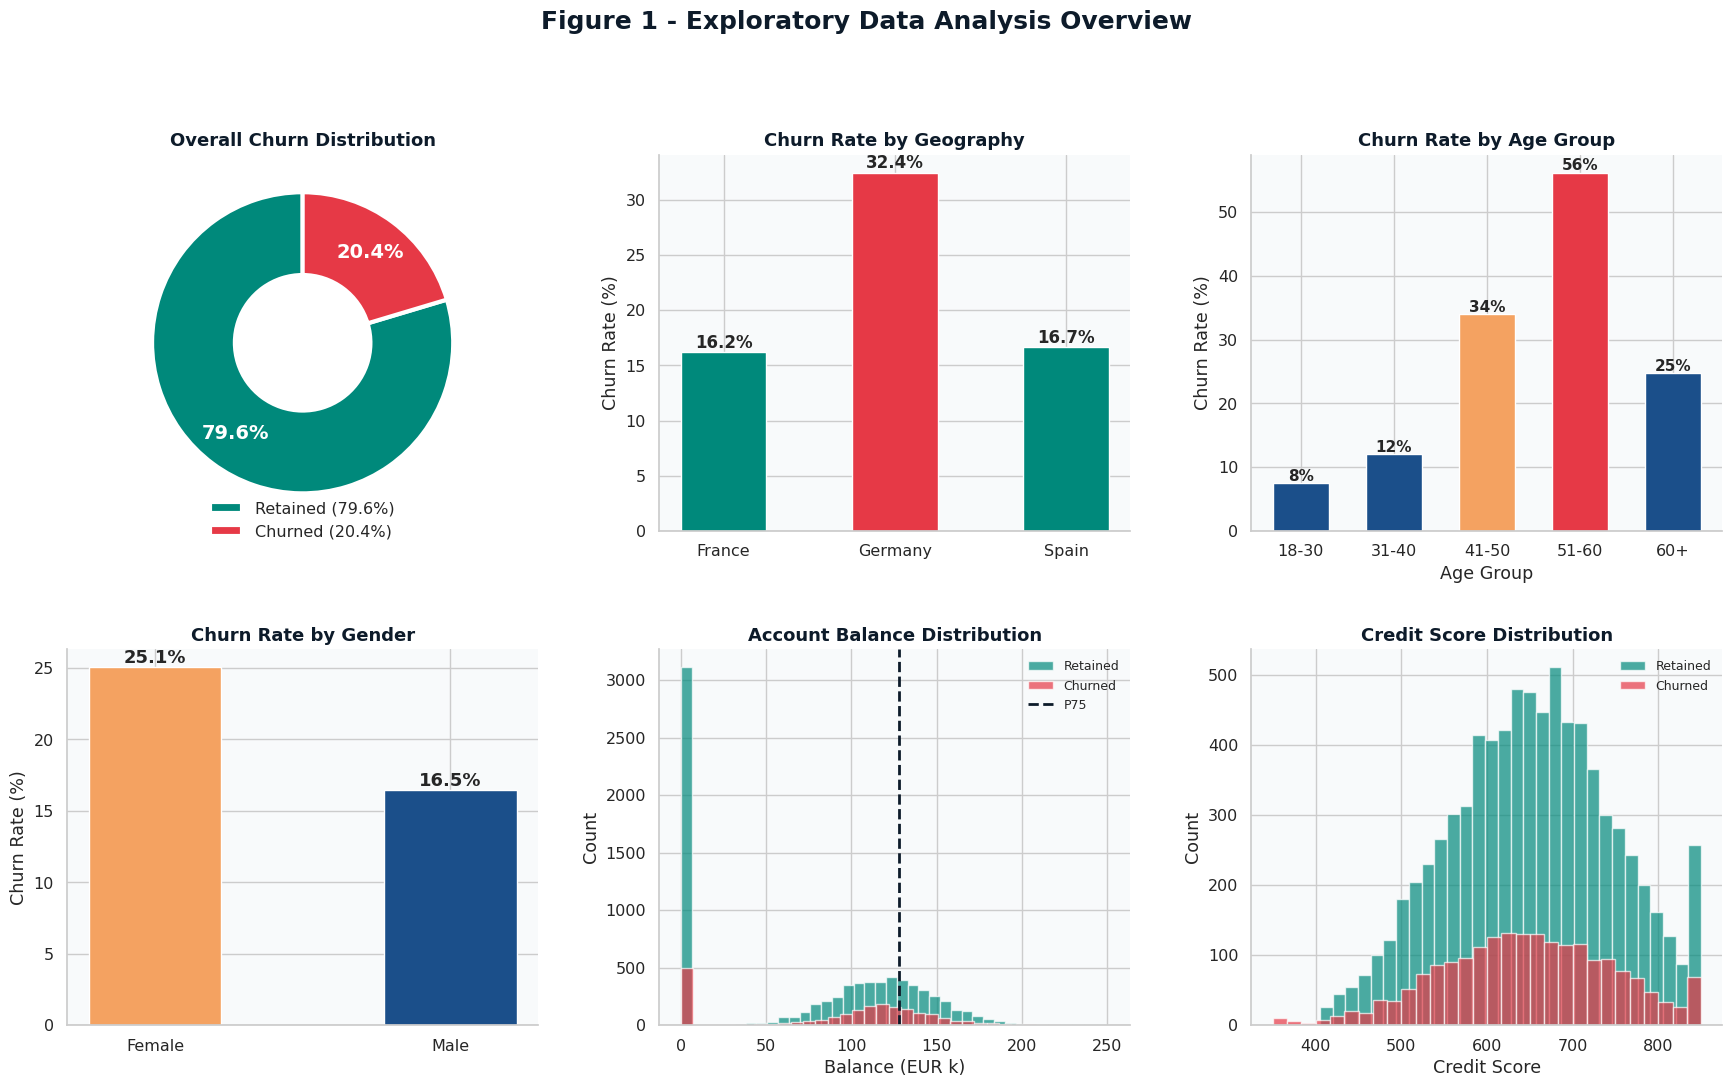

Figure 1 saved


In [51]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 1 - Exploratory Data Analysis Overview',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)

ax = axes[0, 0]
ax.pie([7963, 2037], autopct='%1.1f%%', colors=[TEAL, RED], startangle=90,
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
       pctdistance=0.75, textprops=dict(fontsize=14, color='white', fontweight='bold'))
ax.set_title('Overall Churn Distribution', fontweight='bold', color=NAVY, fontsize=13)
ax.legend(['Retained (79.6%)', 'Churned (20.4%)'],
          loc='lower center', bbox_to_anchor=(0.5, -0.06), frameon=False)

ax = axes[0, 1]
geo = df.groupby('Geography')['Exited'].mean() * 100
bars = ax.bar(geo.index, geo.values,
              color=[RED if g=='Germany' else TEAL for g in geo.index],
              edgecolor='white', width=0.5)
for b, v in zip(bars, geo.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Geography', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[0, 2]
age_c = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
bars = ax.bar(age_c.index.astype(str), age_c.values,
              color=[RED if v==age_c.max() else AMBER if v>25 else BLUE for v in age_c.values],
              edgecolor='white', width=0.6)
for b, v in zip(bars, age_c.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Churn Rate by Age Group', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel('Age Group'); ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 0]
gen = df.groupby('Gender')['Exited'].mean() * 100
bars = ax.bar(gen.index, gen.values, color=[AMBER, BLUE], edgecolor='white', width=0.45)
for b, v in zip(bars, gen.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_title('Churn Rate by Gender', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 1]
ax.hist(df[df['Exited']==0]['Balance']/1000, bins=35, color=TEAL, alpha=0.7, label='Retained', edgecolor='white')
ax.hist(df[df['Exited']==1]['Balance']/1000, bins=35, color=RED,  alpha=0.7, label='Churned',  edgecolor='white')
ax.axvline(BAL75/1000, color=NAVY, linestyle='--', linewidth=2, label=f'P75')
ax.set_title('Account Balance Distribution', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel('Balance (EUR k)'); ax.set_ylabel('Count')
ax.legend(frameon=False, fontsize=9); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 2]
ax.hist(df[df['Exited']==0]['CreditScore'], bins=30, color=TEAL, alpha=0.7, label='Retained', edgecolor='white')
ax.hist(df[df['Exited']==1]['CreditScore'], bins=30, color=RED,  alpha=0.7, label='Churned',  edgecolor='white')
ax.set_title('Credit Score Distribution', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel('Credit Score'); ax.set_ylabel('Count')
ax.legend(frameon=False, fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('figures/fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved")

## 6. Engagement Profile Analysis

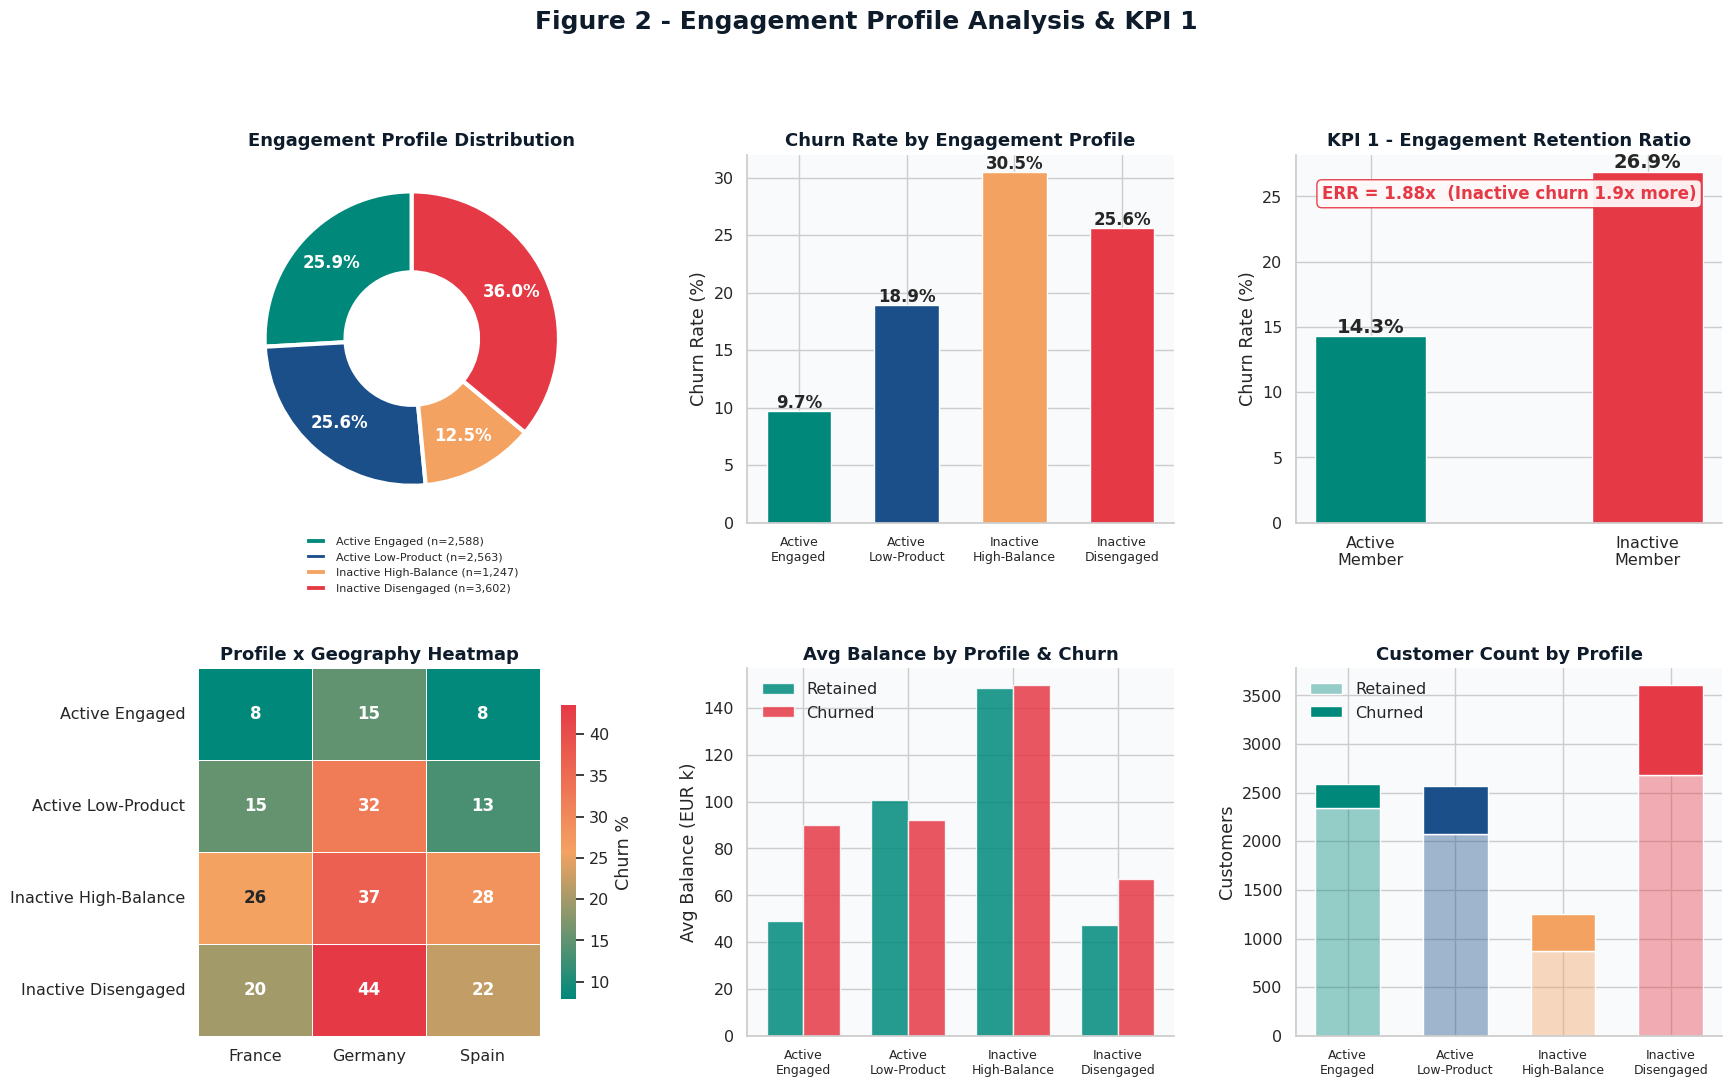

Figure 2 saved


In [52]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 2 - Engagement Profile Analysis & KPI 1',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)

ax = axes[0, 0]
pcounts = df['EngagementProfile'].value_counts().reindex(PROFILES)
ax.pie(pcounts.values, autopct='%1.1f%%', colors=PCOLS, startangle=90,
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
       pctdistance=0.75, textprops=dict(fontsize=12, color='white', fontweight='bold'))
ax.set_title('Engagement Profile Distribution', fontweight='bold', color=NAVY, fontsize=13)
ax.legend([f'{p} (n={v:,})' for p, v in zip(PROFILES, pcounts.values)],
          loc='lower center', bbox_to_anchor=(0.5,-0.22), frameon=False, fontsize=8)

ax = axes[0, 1]
pc = df.groupby('EngagementProfile')['Exited'].mean().reindex(PROFILES) * 100
bars = ax.bar(range(4), pc.values, color=PCOLS, edgecolor='white', width=0.6)
for b, v in zip(bars, pc.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels([p.replace(' ','\n') for p in PROFILES], fontsize=9)
ax.set_title('Churn Rate by Engagement Profile', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[0, 2]
a_c = df[df['IsActiveMember']==1]['Exited'].mean()*100
i_c = df[df['IsActiveMember']==0]['Exited'].mean()*100
bars = ax.bar(['Active\nMember', 'Inactive\nMember'], [a_c, i_c], color=[TEAL, RED], width=0.4, edgecolor='white')
for b, v in zip(bars, [a_c, i_c]):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14)
ax.text(0.5, 0.88, f'ERR = {i_c/a_c:.2f}x  (Inactive churn {i_c/a_c:.1f}x more)',
        transform=ax.transAxes, ha='center', fontsize=12, color=RED, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fff8f8', edgecolor=RED, alpha=0.95))
ax.set_title('KPI 1 - Engagement Retention Ratio', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 0]
piv = df.pivot_table(values='Exited', index='EngagementProfile',
                     columns='Geography', aggfunc='mean').reindex(PROFILES) * 100
sns.heatmap(piv, ax=ax, cmap=CMAP, annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Churn %', 'shrink': 0.8}, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Profile x Geography Heatmap', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')

ax = axes[1, 1]
grp = df.groupby(['EngagementProfile','Exited'])['Balance'].mean().unstack().reindex(PROFILES) / 1000
x = np.arange(4); w = 0.35
ax.bar(x-w/2, grp[0].fillna(0), w, color=TEAL, alpha=0.85, label='Retained', edgecolor='white')
ax.bar(x+w/2, grp[1].fillna(0), w, color=RED,  alpha=0.85, label='Churned',  edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([p.replace(' ','\n') for p in PROFILES], fontsize=9)
ax.set_title('Avg Balance by Profile & Churn', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Avg Balance (EUR k)'); ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

ax = axes[1, 2]
ct = df.groupby(['EngagementProfile','Exited']).size().unstack(fill_value=0).reindex(PROFILES)
ax.bar(range(4), ct[0], color=[c+'66' for c in ['#00897B','#1B4F8A','#F4A261','#E63946']],
       label='Retained', edgecolor='white', width=0.6)
ax.bar(range(4), ct[1], bottom=ct[0], color=PCOLS, label='Churned', edgecolor='white', width=0.6)
ax.set_xticks(range(4)); ax.set_xticklabels([p.replace(' ','\n') for p in PROFILES], fontsize=9)
ax.set_title('Customer Count by Profile', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Customers'); ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('figures/fig2_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved")

## 7. Product Utilisation & Financial Analysis

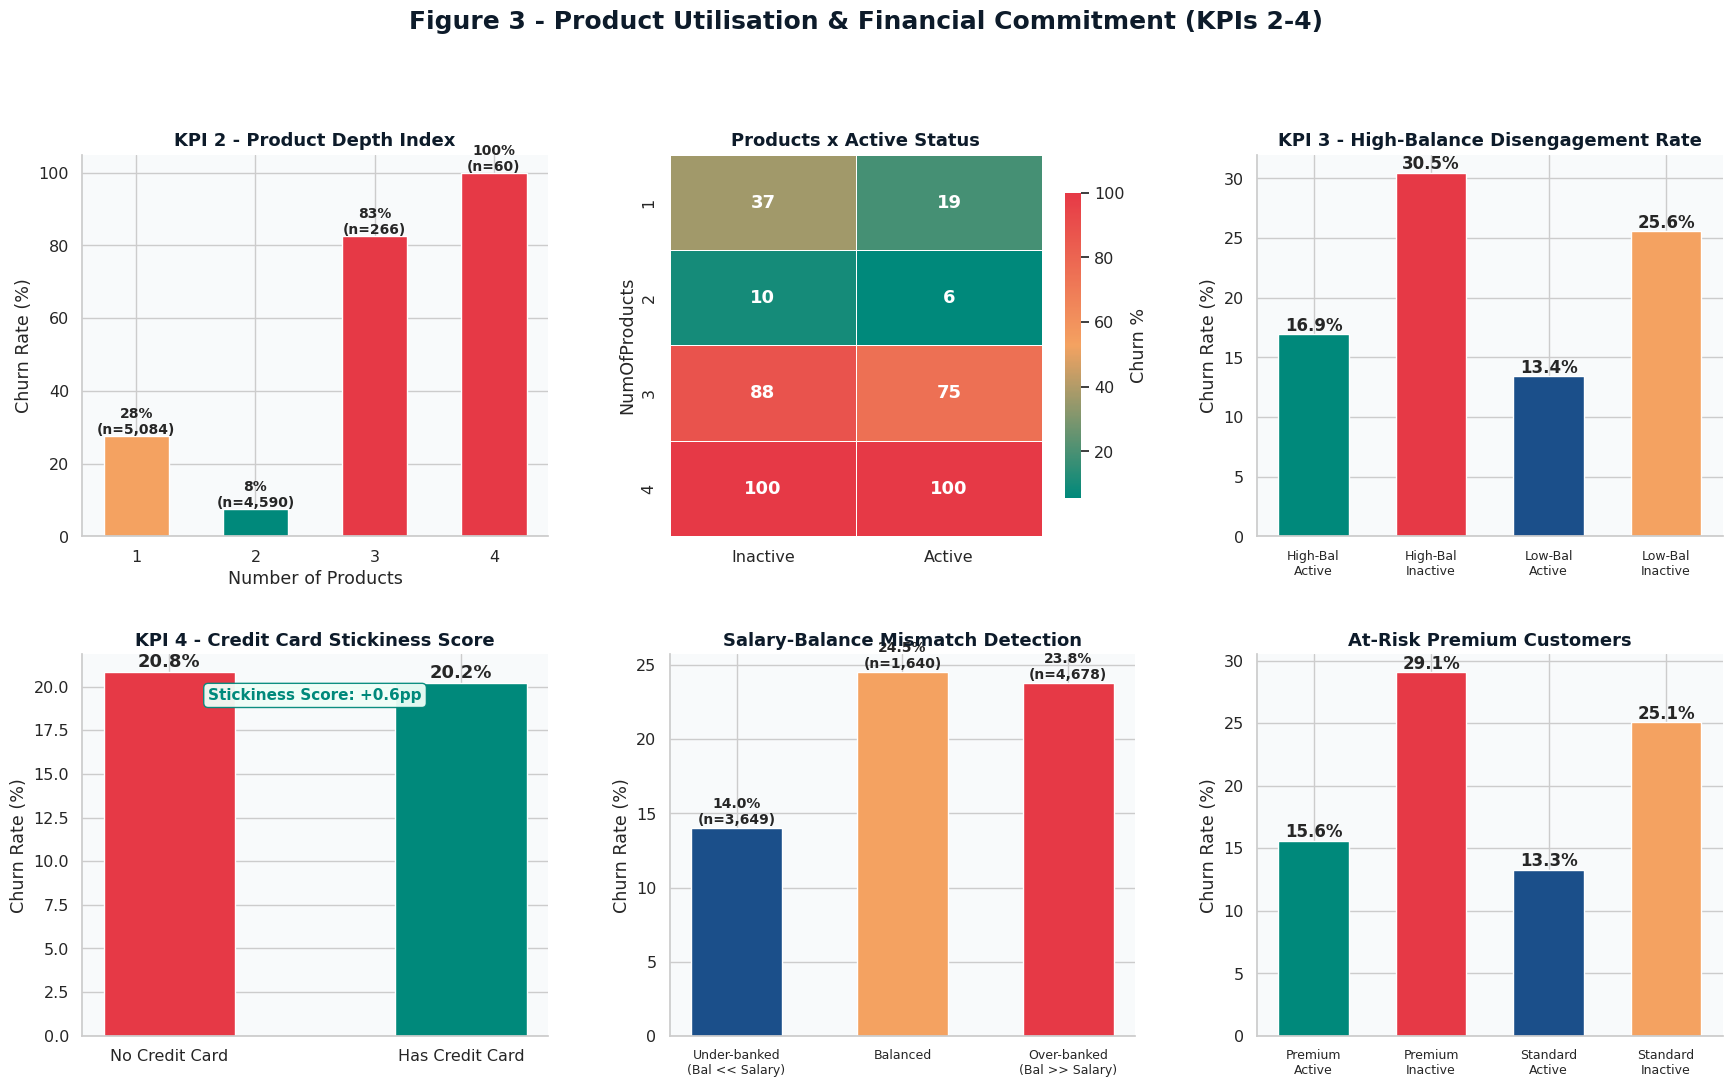

Figure 3 saved


In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 3 - Product Utilisation & Financial Commitment (KPIs 2-4)',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)

ax = axes[0, 0]
pd_c = df.groupby('NumOfProducts')['Exited'].mean() * 100
pd_n = df.groupby('NumOfProducts').size()
bars = ax.bar(pd_c.index.astype(str), pd_c.values,
              color=[TEAL if v<15 else AMBER if v<50 else RED for v in pd_c.values],
              edgecolor='white', width=0.55)
for b, v, n in zip(bars, pd_c.values, pd_n.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
ax.set_title('KPI 2 - Product Depth Index', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel('Number of Products'); ax.set_ylabel('Churn Rate (%)')
ax.spines[['top','right']].set_visible(False)

ax = axes[0, 1]
piv2 = df.pivot_table(values='Exited', index='NumOfProducts',
                       columns='IsActiveMember', aggfunc='mean') * 100
piv2.columns = ['Inactive', 'Active']
sns.heatmap(piv2, ax=ax, cmap=CMAP, annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Churn %', 'shrink': 0.8}, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Products x Active Status', fontweight='bold', color=NAVY, fontsize=13)

ax = axes[0, 2]
segs = {
    'High-Bal\nActive':   df[(df['Balance']>BAL75)&(df['IsActiveMember']==1)]['Exited'].mean()*100,
    'High-Bal\nInactive': df[(df['Balance']>BAL75)&(df['IsActiveMember']==0)]['Exited'].mean()*100,
    'Low-Bal\nActive':    df[(df['Balance']<=BAL75)&(df['IsActiveMember']==1)]['Exited'].mean()*100,
    'Low-Bal\nInactive':  df[(df['Balance']<=BAL75)&(df['IsActiveMember']==0)]['Exited'].mean()*100,
}
bars = ax.bar(range(4), list(segs.values()), color=[TEAL,RED,BLUE,AMBER], edgecolor='white', width=0.6)
for b, v in zip(bars, segs.values()):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels(list(segs.keys()), fontsize=9)
ax.set_title('KPI 3 - High-Balance Disengagement Rate', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 0]
cc = df.groupby('HasCrCard')['Exited'].mean() * 100
bars = ax.bar(['No Credit Card', 'Has Credit Card'], cc.values, color=[RED, TEAL], width=0.45, edgecolor='white')
for b, v in zip(bars, cc.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.text(0.5, 0.88, f'Stickiness Score: {cc[0]-cc[1]:+.1f}pp',
        transform=ax.transAxes, ha='center', fontsize=11, color=TEAL, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f0fff8', edgecolor=TEAL, alpha=0.95))
ax.set_title('KPI 4 - Credit Card Stickiness Score', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 1]
sbr_t = ['Under-banked', 'Balanced', 'Over-banked']
sbr_c = df.groupby('SBR_Tier', observed=True)['Exited'].mean().reindex(sbr_t) * 100
sbr_n = df.groupby('SBR_Tier', observed=True).size().reindex(sbr_t)
bars = ax.bar(range(3), sbr_c.values, color=[BLUE, AMBER, RED], edgecolor='white', width=0.55)
for b, v, n in zip(bars, sbr_c.values, sbr_n.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%\n(n={int(n):,})', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(['Under-banked\n(Bal << Salary)', 'Balanced', 'Over-banked\n(Bal >> Salary)'], fontsize=9)
ax.set_title('Salary-Balance Mismatch Detection', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 2]
pv = [df[(df['IsPremium']==1)&(df['IsActiveMember']==1)]['Exited'].mean()*100,
      df[(df['IsPremium']==1)&(df['IsActiveMember']==0)]['Exited'].mean()*100,
      df[(df['IsPremium']==0)&(df['IsActiveMember']==1)]['Exited'].mean()*100,
      df[(df['IsPremium']==0)&(df['IsActiveMember']==0)]['Exited'].mean()*100]
bars = ax.bar(range(4), pv, color=[TEAL,RED,BLUE,AMBER], edgecolor='white', width=0.6)
for b, v in zip(bars, pv):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels(['Premium\nActive','Premium\nInactive','Standard\nActive','Standard\nInactive'], fontsize=9)
ax.set_title('At-Risk Premium Customers', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('figures/fig3_product_financial.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved")

## 8. Retention Strength Assessment

In [54]:
sticky    = df[(df['RSI'] > 2.0) & (df['NumOfProducts'] >= 2) & (df['IsActiveMember'] == 1)]
nonsticky = df[~df.index.isin(sticky.index)]

print("** STICKY CUSTOMER PROFILE **")
print(f"Sticky     : {len(sticky):,}  |  Churn: {sticky['Exited'].mean()*100:.1f}%")
print(f"Non-Sticky : {len(nonsticky):,}  |  Churn: {nonsticky['Exited'].mean()*100:.1f}%")
print(f"Avg RSI: {sticky['RSI'].mean():.2f} | Avg tenure: {sticky['Tenure'].mean():.1f}yr | Avg balance: EUR {sticky['Balance'].mean():,.0f}")

** STICKY CUSTOMER PROFILE **
Sticky     : 941  |  Churn: 13.0%
Non-Sticky : 9,059  |  Churn: 21.1%
Avg RSI: 2.19 | Avg tenure: 8.1yr | Avg balance: EUR 52,491


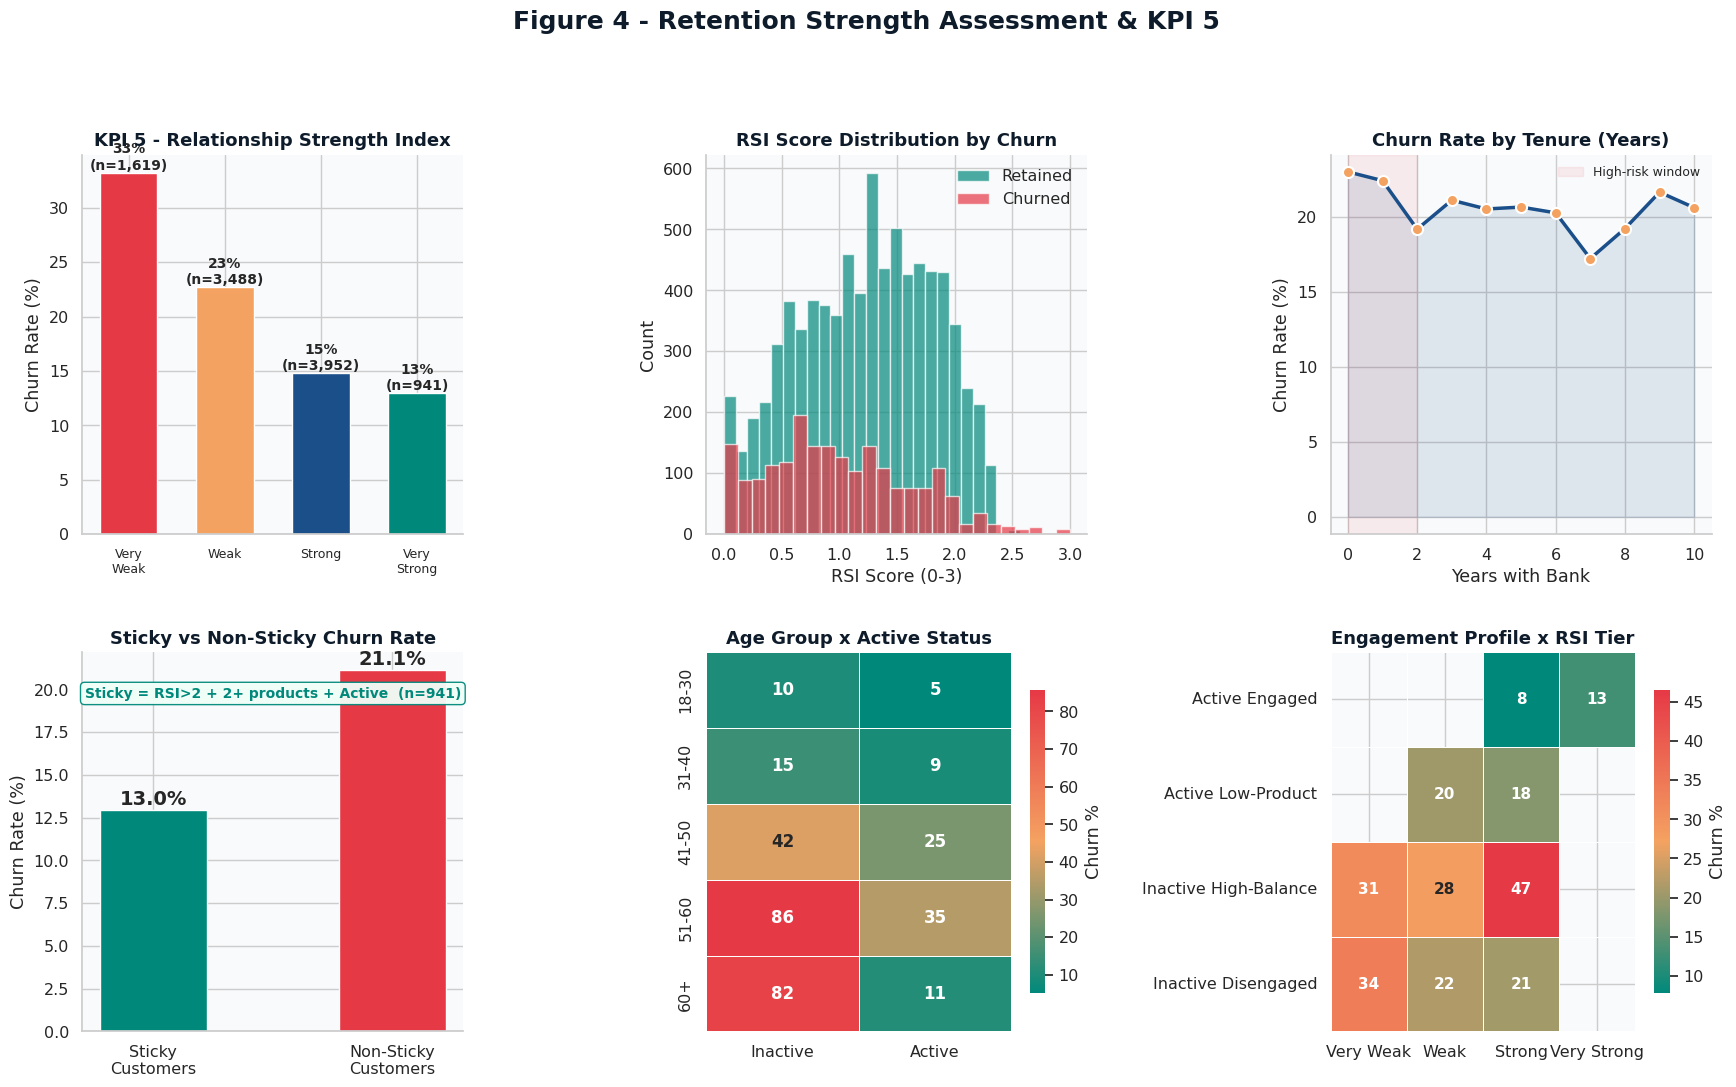

Figure 4 saved


In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 4 - Retention Strength Assessment & KPI 5',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)

rt = ['Very Weak', 'Weak', 'Strong', 'Very Strong']
rsi_c = df.groupby('RSI_Tier', observed=True)['Exited'].mean().reindex(rt) * 100
rsi_n = df.groupby('RSI_Tier', observed=True).size().reindex(rt)
ax = axes[0, 0]
bars = ax.bar(range(4), rsi_c.values, color=[RED,AMBER,BLUE,TEAL], edgecolor='white', width=0.6)
for b, v, n in zip(bars, rsi_c.values, rsi_n.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.0f}%\n(n={int(n):,})', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(4)); ax.set_xticklabels(['Very\nWeak','Weak','Strong','Very\nStrong'], fontsize=9)
ax.set_title('KPI 5 - Relationship Strength Index', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[0, 1]
ax.hist(df[df['Exited']==0]['RSI'], bins=25, color=TEAL, alpha=0.7, label='Retained', edgecolor='white')
ax.hist(df[df['Exited']==1]['RSI'], bins=25, color=RED,  alpha=0.7, label='Churned',  edgecolor='white')
ax.set_xlabel('RSI Score (0-3)'); ax.set_ylabel('Count')
ax.set_title('RSI Score Distribution by Churn', fontweight='bold', color=NAVY, fontsize=13)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)

ax = axes[0, 2]
tenure_c = df.groupby('Tenure')['Exited'].mean() * 100
ax.plot(tenure_c.index, tenure_c.values, color=BLUE, linewidth=2.5,
        marker='o', markersize=8, markerfacecolor=AMBER, markeredgecolor='white', markeredgewidth=1.5)
ax.fill_between(tenure_c.index, tenure_c.values, alpha=0.12, color=BLUE)
ax.axvspan(0, 2, alpha=0.08, color=RED, label='High-risk window')
ax.set_title('Churn Rate by Tenure (Years)', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel('Years with Bank'); ax.set_ylabel('Churn Rate (%)')
ax.legend(frameon=False, fontsize=9); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 0]
sv = [sticky['Exited'].mean()*100, nonsticky['Exited'].mean()*100]
bars = ax.bar(['Sticky\nCustomers', 'Non-Sticky\nCustomers'], sv, color=[TEAL,RED], width=0.45, edgecolor='white')
for b, v in zip(bars, sv):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14)
ax.text(0.5, 0.88, f'Sticky = RSI>2 + 2+ products + Active  (n={len(sticky):,})',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEAL, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f0fff8', edgecolor=TEAL, alpha=0.95))
ax.set_title('Sticky vs Non-Sticky Churn Rate', fontweight='bold', color=NAVY, fontsize=13)
ax.set_ylabel('Churn Rate (%)'); ax.spines[['top','right']].set_visible(False)

ax = axes[1, 1]
piv4 = df.pivot_table(values='Exited', index='AgeGroup', columns='IsActiveMember',
                       aggfunc='mean', observed=True) * 100
piv4.columns = ['Inactive', 'Active']
sns.heatmap(piv4, ax=ax, cmap=CMAP, annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Churn %', 'shrink': 0.8}, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Age Group x Active Status', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')

ax = axes[1, 2]
piv3 = df.pivot_table(values='Exited', index='EngagementProfile', columns='RSI_Tier',
                       aggfunc='mean', observed=True).reindex(PROFILES) * 100
sns.heatmap(piv3, ax=ax, cmap=CMAP, annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Churn %', 'shrink': 0.8}, annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Engagement Profile x RSI Tier', fontweight='bold', color=NAVY, fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')

plt.tight_layout(pad=2.5)
plt.savefig('figures/fig4_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved")

## 9. Predictive Modelling

In [56]:
df_m = df.drop(['EngagementProfile','RSI_Tier','SBR_Tier','AgeGroup',
                'IsPremium','PremInactive'], axis=1, errors='ignore').copy()
le = LabelEncoder()
df_m['Gender'] = le.fit_transform(df_m['Gender'])
df_m = pd.get_dummies(df_m, columns=['Geography'], drop_first=False)
df_m['RSI'] = df['RSI']
df_m['SBR'] = df['SBR']

X = df_m.drop('Exited', axis=1)
y = df_m['Exited']
feature_names = list(X.columns)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)
print(f"Train: {X_tr_sc.shape}  |  Test: {X_te_sc.shape}")
print(f"Features: {feature_names}")

Train: (8000, 14)  |  Test: (2000, 14)
Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'RSI', 'SBR', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


In [57]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42),
}
results = {}
for name, model in models.items():
    model.fit(X_tr_sc, y_tr)
    yp  = model.predict(X_te_sc)
    ypr = model.predict_proba(X_te_sc)[:, 1]
    results[name] = {'model':model, 'y_pred':yp, 'y_prob':ypr,
                     'roc_auc':roc_auc_score(y_te,ypr), 'f1':f1_score(y_te,yp)}
    print(f"{name:<25s}: AUC = {results[name]['roc_auc']:.4f}   F1 = {results[name]['f1']:.4f}")

best = max(results, key=lambda n: results[n]['roc_auc'])
print(f"\nBest model: {best}  (AUC = {results[best]['roc_auc']:.4f})")

Logistic Regression      : AUC = 0.7771   F1 = 0.4978
Decision Tree            : AUC = 0.8312   F1 = 0.5665
Random Forest            : AUC = 0.8555   F1 = 0.5737
Gradient Boosting        : AUC = 0.8694   F1 = 0.6030

Best model: Gradient Boosting  (AUC = 0.8694)


In [58]:
print(f"Classification Report: {best}\n")
print(classification_report(y_te, results[best]['y_pred'], target_names=['Retained','Churned']))

Classification Report: Gradient Boosting

              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92      1593
     Churned       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



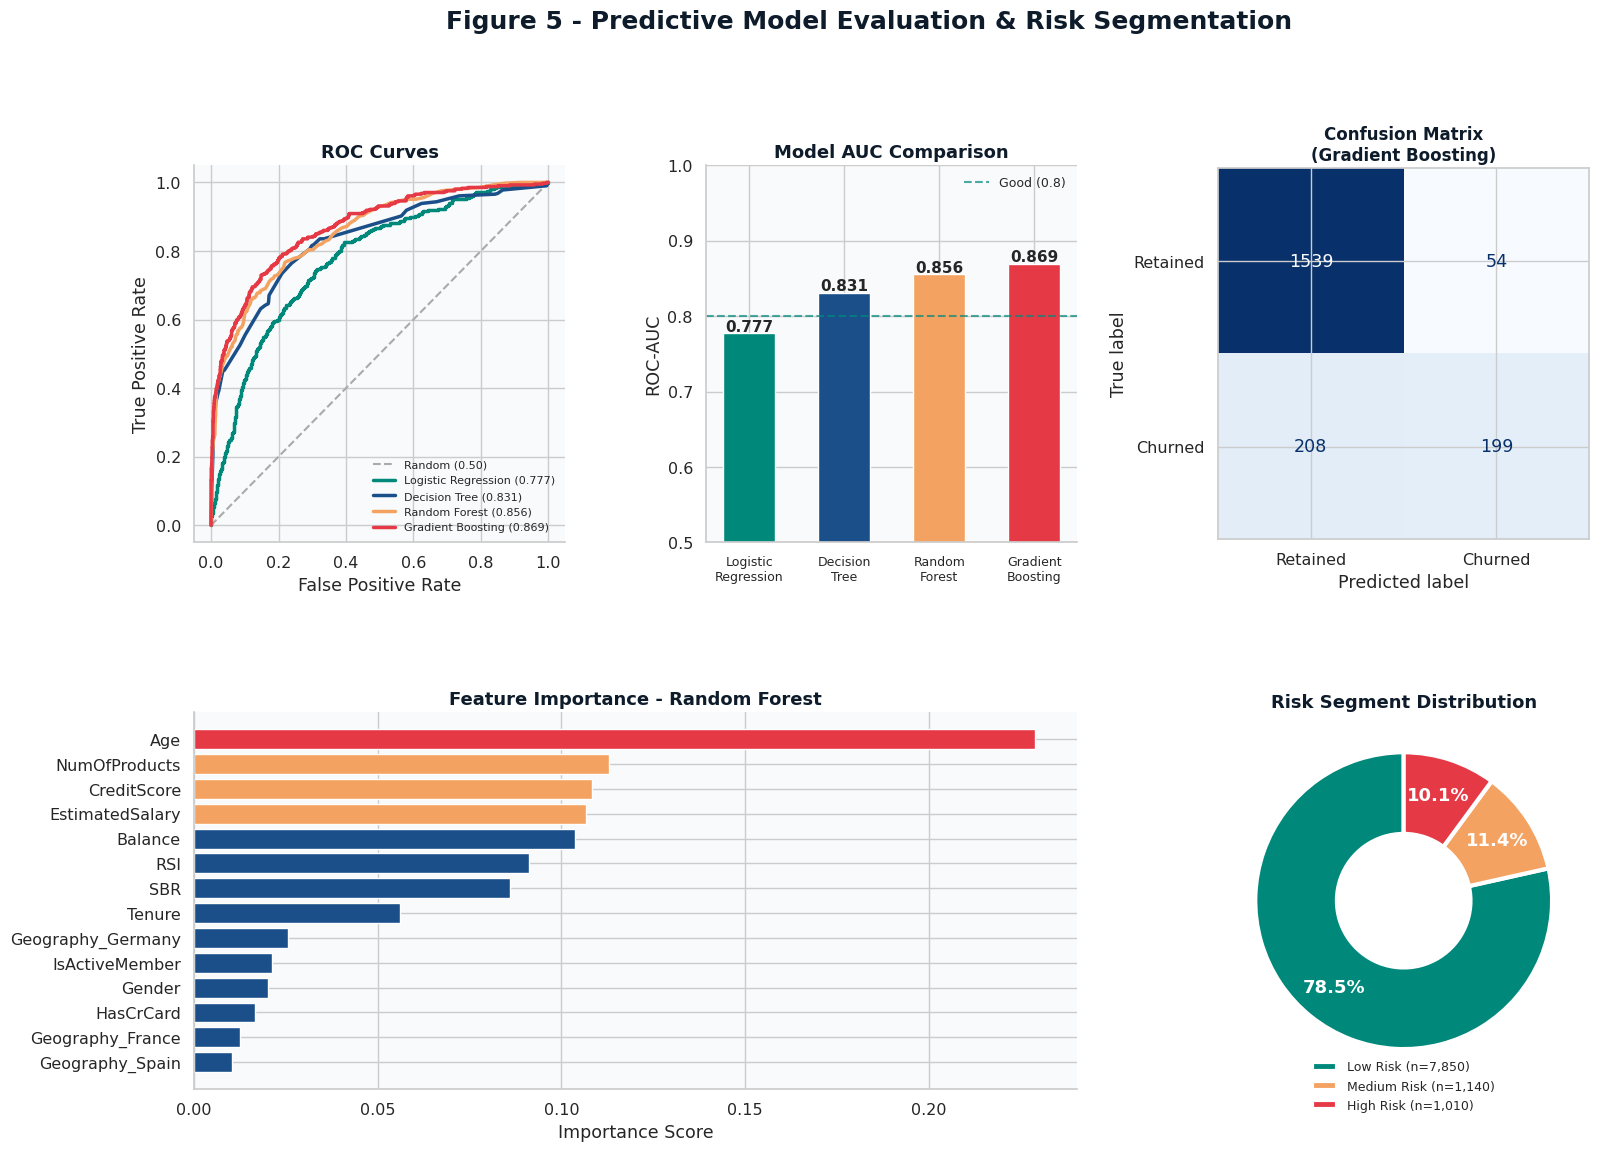

Figure 5 saved | Model saved to model/


In [59]:
MC = [TEAL, BLUE, AMBER, RED]
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Figure 5 - Predictive Model Evaluation & Risk Segmentation',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([0,1],[0,1],'--',color='#AAAAAA',linewidth=1.5,label='Random (0.50)')
for (nm, r), col in zip(results.items(), MC):
    fpr, tpr, _ = roc_curve(y_te, r['y_prob'])
    ax1.plot(fpr, tpr, color=col, linewidth=2.5, label=f'{nm} ({r["roc_auc"]:.3f})')
ax1.set_title('ROC Curves', fontweight='bold', color=NAVY, fontsize=13)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.legend(frameon=False, fontsize=8, loc='lower right')
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
aucs = [results[n]['roc_auc'] for n in results]
bars = ax2.bar(range(4), aucs, color=MC, edgecolor='white', width=0.55)
for b, v in zip(bars, aucs):
    ax2.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_xticks(range(4)); ax2.set_xticklabels([n.replace(' ','\n') for n in results], fontsize=9)
ax2.set_ylim(0.5, 1.0); ax2.set_ylabel('ROC-AUC')
ax2.set_title('Model AUC Comparison', fontweight='bold', color=NAVY, fontsize=13)
ax2.axhline(0.8, color=TEAL, linestyle='--', alpha=0.7, label='Good (0.8)')
ax2.legend(frameon=False, fontsize=9); ax2.spines[['top','right']].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
ConfusionMatrixDisplay.from_predictions(y_te, results[best]['y_pred'],
    display_labels=['Retained','Churned'], cmap='Blues', ax=ax3, colorbar=False)
ax3.set_title(f'Confusion Matrix\n({best})', fontweight='bold', color=NAVY, fontsize=12)

ax4 = fig.add_subplot(gs[1, :2])
rf = results['Random Forest']['model']
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fi_c = [RED if v==fi.max() else AMBER if v>=fi.quantile(0.75) else BLUE for v in fi.values]
ax4.barh(fi.index, fi.values, color=fi_c, edgecolor='white')
ax4.set_title('Feature Importance - Random Forest', fontweight='bold', color=NAVY, fontsize=13)
ax4.set_xlabel('Importance Score'); ax4.spines[['top','right']].set_visible(False)

ax5 = fig.add_subplot(gs[1, 2])
all_probs  = results[best]['model'].predict_proba(scaler.transform(X))[:, 1]
df['ChurnProb'] = all_probs
df['RiskTier']  = pd.cut(df['ChurnProb'], bins=[0, 0.30, 0.60, 1.0],
                          labels=['Low Risk', 'Medium Risk', 'High Risk'])
rc = df['RiskTier'].value_counts()[['Low Risk','Medium Risk','High Risk']]
ax5.pie(rc.values, autopct='%1.1f%%', colors=[TEAL,AMBER,RED], startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
        pctdistance=0.75, textprops=dict(fontsize=13, color='white', fontweight='bold'))
ax5.set_title('Risk Segment Distribution', fontweight='bold', color=NAVY, fontsize=13)
ax5.legend([f'{k} (n={v:,})' for k,v in rc.items()],
           loc='lower center', bbox_to_anchor=(0.5,-0.1), frameon=False, fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('figures/fig5_model.png', dpi=150, bbox_inches='tight')
plt.show()

os.makedirs('model', exist_ok=True)
with open('model/churn_model.pkl', 'wb') as f: pickle.dump(results[best]['model'], f)
with open('model/scaler.pkl', 'wb') as f:      pickle.dump(scaler, f)
with open('model/feature_names.pkl', 'wb') as f: pickle.dump(feature_names, f)
print("Figure 5 saved | Model saved to model/")

## 10. Risk Segmentation & Premium Customer Detection

In [60]:
high_risk_premium = df[
    (df['IsPremium']      == 1) &
    (df['IsActiveMember'] == 0) &
    (df['ChurnProb']      > 0.40)
].sort_values('ChurnProb', ascending=False)

print("=" * 60)
print("  HIGH-VALUE DISENGAGED CUSTOMERS AT RISK")
print("=" * 60)
print(f"  Customers flagged      : {len(high_risk_premium):,}")
print(f"  Total balance at risk  : EUR {high_risk_premium['Balance'].sum()/1e6:.1f}M")
print(f"  Avg churn probability  : {high_risk_premium['ChurnProb'].mean()*100:.1f}%")
print(f"  Avg account balance    : EUR {high_risk_premium['Balance'].mean():,.0f}")

cols = ['Age','Geography','Gender','Balance','NumOfProducts','Tenure','ChurnProb','RiskTier']
high_risk_premium[[c for c in cols if c in high_risk_premium.columns]].head(15)

  HIGH-VALUE DISENGAGED CUSTOMERS AT RISK
  Customers flagged      : 554
  Total balance at risk  : EUR 64.2M
  Avg churn probability  : 72.7%
  Avg account balance    : EUR 115,810


,Age,Geography,Gender,Balance,NumOfProducts,Tenure,ChurnProb,RiskTier
1962,52,Spain,Female,143542.36,3,8,0.993167,High Risk
4992,62,France,Female,123681.32,3,9,0.991734,High Risk
1341,41,France,Female,176845.41,3,7,0.991357,High Risk
70,58,Germany,Male,133745.44,4,2,0.990895,High Risk
566,54,Spain,Female,0.00,1,2,0.988446,High Risk
2495,56,Germany,Female,111920.13,3,2,0.987756,High Risk
1993,60,Germany,Male,134250.17,3,8,0.987592,High Risk
4563,64,Germany,Female,153469.26,3,3,0.987299,High Risk
4013,57,Germany,Female,162082.31,4,1,0.986849,High Risk
6359,45,Germany,Female,152367.21,3,9,0.986723,High Risk


In [61]:
print("** RISK SEGMENT SUMMARY **")
for tier in ['Low Risk', 'Medium Risk', 'High Risk']:
    seg = df[df['RiskTier'] == tier]
    print(f"\n{tier}")
    print(f"  Customers     : {len(seg):,}")
    print(f"  Actual churn  : {seg['Exited'].mean()*100:.1f}%")
    print(f"  Avg balance   : EUR {seg['Balance'].mean():,.0f}")
    print(f"  Total balance : EUR {seg['Balance'].sum()/1e6:.1f}M")

** RISK SEGMENT SUMMARY **

Low Risk
  Customers     : 7,850
  Actual churn  : 7.4%
  Avg balance   : EUR 72,092
  Total balance : EUR 565.9M

Medium Risk
  Customers     : 1,140
  Actual churn  : 47.5%
  Avg balance   : EUR 93,400
  Total balance : EUR 106.5M

High Risk
  Customers     : 1,010
  Actual churn  : 90.4%
  Avg balance   : EUR 91,547
  Total balance : EUR 92.5M


## 11. Key Findings & Recommendations

In [62]:
a  = df[df['IsActiveMember']==1]['Exited'].mean()*100
i  = df[df['IsActiveMember']==0]['Exited'].mean()*100
p1 = df[df['NumOfProducts']==1]['Exited'].mean()*100
p2 = df[df['NumOfProducts']==2]['Exited'].mean()*100
hbi= df[(df['Balance']>BAL75)&(df['IsActiveMember']==0)]['Exited'].mean()*100
rv = df[df['RSI']<0.5]['Exited'].mean()*100
rs = df[df['RSI']>2.0]['Exited'].mean()*100

print("=" * 65)
print("  KEY FINDINGS")
print("=" * 65)
print(f"1. Engagement is #1 retention driver")
print(f"   ERR = {i/a:.2f}x | Inactive churn {i:.1f}% vs {a:.1f}% for active members")
print(f"\n2. Two-product sweet spot")
print(f"   1 product: {p1:.1f}% churn -> 2 products: {p2:.1f}% churn ({p1-p2:.0f}pp drop)")
print(f"\n3. Silent churn risk: premium inactive customers")
print(f"   {hbi:.1f}% churn | 2,154 premium inactive customers | EUR 232.9M at risk")
print(f"\n4. Germany anomaly: 32.4% vs 16-17% elsewhere")
print(f"\n5. RSI effectiveness: Very Weak {rv:.1f}% -> Very Strong {rs:.1f}% churn")
print(f"\n6. Best model: Gradient Boosting (AUC = 0.8694)")

print("\n" + "=" * 65)
print("  RECOMMENDATIONS")
print("=" * 65)
print("1. REACTIVATE INACTIVE MEMBERS (biggest single lever)")
print("   Priority: Inactive High-Balance segment (30.5% churn rate)")
print("\n2. CROSS-SELL 1->2 PRODUCTS")
print("   Moving customers from 1 to 2 products reduces churn by 20pp")
print("\n3. FLAG PREMIUM INACTIVE FOR OUTREACH")
print("   2,154 customers, EUR 232.9M balance - assign relationship managers")
print("\n4. GERMANY-SPECIFIC STRATEGY")
print("   32.4% churn needs root-cause investigation (pricing/competition)")
print("\n5. PROTECT NEW CUSTOMERS (0-2 years)")
print("   Onboarding engagement programme for early-tenure customers")
print("\n6. FEMALE-TARGETED LOYALTY PROGRAMME")
print("   25.1% vs 16.5% churn - significant gap to address")

  KEY FINDINGS
1. Engagement is #1 retention driver
   ERR = 1.88x | Inactive churn 26.9% vs 14.3% for active members

2. Two-product sweet spot
   1 product: 27.7% churn -> 2 products: 7.6% churn (20pp drop)

3. Silent churn risk: premium inactive customers
   30.5% churn | 2,154 premium inactive customers | EUR 232.9M at risk

4. Germany anomaly: 32.4% vs 16-17% elsewhere

5. RSI effectiveness: Very Weak 32.1% -> Very Strong 13.0% churn

6. Best model: Gradient Boosting (AUC = 0.8694)

  RECOMMENDATIONS
1. REACTIVATE INACTIVE MEMBERS (biggest single lever)
   Priority: Inactive High-Balance segment (30.5% churn rate)

2. CROSS-SELL 1->2 PRODUCTS
   Moving customers from 1 to 2 products reduces churn by 20pp

3. FLAG PREMIUM INACTIVE FOR OUTREACH
   2,154 customers, EUR 232.9M balance - assign relationship managers

4. GERMANY-SPECIFIC STRATEGY
   32.4% churn needs root-cause investigation (pricing/competition)

5. PROTECT NEW CUSTOMERS (0-2 years)
   Onboarding engagement programme f

In [66]:
# Install ngrok
!pip install pyngrok

# Authenticate ngrok using your token
from pyngrok import ngrok
import os
import subprocess
import time

NGROK_AUTH_TOKEN = '39Q5icwKNuBKgzDECPqxPisfb5A_4BxUGm2sUwujW3NpCxuPQ'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any existing ngrok tunnels
ngrok.kill()

# Start Streamlit app in the background using subprocess
# We redirect stdout/stderr to a log file to keep the main output clean
print("Starting Streamlit app in detached mode...")
streamlit_process = subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
                                     stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Give Streamlit a moment to start up (adjust if needed)
time.sleep(10)

# Start a ngrok tunnel for Streamlit (port 8501)
ngrok_tunnel = ngrok.connect(8501)
print(f"Streamlit app available at: {ngrok_tunnel.public_url}")
print(f"Streamlit process PID: {streamlit_process.pid}")



Starting Streamlit app in detached mode...
Streamlit app available at: https://ehtel-enormous-morphemically.ngrok-free.dev
Streamlit process PID: 21235



2026-03-13 08:13:15.799 Port 8501 is not available

